# DNA Fiber Assay Analysis of ORC1 aptamers


**Purpose:** Compare replication speed and inter-origin distance between WT and MGS variants.

**Author:** Elena Lopatukhina
**Date:** 2026-07-15

## Workflow
1. Parameters import
2. Data loading
3. Data propcessing
4. Basic statistics calculation
5. Processing outliers
6. Statistical analysis
7. Tables export
8. Graphs plot

# 1. Parameters

In [1]:
INPUT_DIR = "/mnt/c/users/helen/Desktop/210926"
OUTPUT_DIR = "/mnt/c/users/helen/Desktop/210926/results"

pixel_size = 0.16125 # µm
conversion_factor = 2.59 # kb/µm
time = 20 # minutes

# 2. Import data

## 2.1 Data loading

In [2]:
from utils import load_data, data_subset

data = load_data(dir = INPUT_DIR, pixel_size=pixel_size)

print(f"Total number of measurements for analysis is: {data.shape[0]}")

Total number of measurements for analysis is: 662


In [3]:
data

,Sample_name,File,Measurement_type,Length,ROI,Path
0,None,Apt1_Interorigin_distance,Interorigin_distance,11.322007,0165-0645,/mnt/c/users/helen/Desktop/210926/apt1_preproc...
1,None,Apt1-02_Fiber_length,Fiber_length,5.407357,0719-0533,/mnt/c/users/helen/Desktop/210926/apt1_preproc...
2,None,Apt1-02_Fiber_length,Fiber_length,7.099193,0718-0579,/mnt/c/users/helen/Desktop/210926/apt1_preproc...
3,None,Apt1-03_Fiber_length,Fiber_length,8.975175,0461-0594,/mnt/c/users/helen/Desktop/210926/apt1_preproc...
4,None,Apt1-03_Fiber_length,Fiber_length,11.918633,0482-0524,/mnt/c/users/helen/Desktop/210926/apt1_preproc...
...,...,...,...,...,...,...
657,None,NC-40_Fiber_length,Fiber_length,6.601898,0063-0573,/mnt/c/users/helen/Desktop/210926/nc_preproces...
658,None,NC-40_Fiber_length,Fiber_length,6.935685,0193-0224,/mnt/c/users/helen/Desktop/210926/nc_preproces...
659,None,NC-40_Fiber_length,Fiber_length,5.983665,0178-0270,/mnt/c/users/helen/Desktop/210926/nc_preproces...
660,None,NC-41_Interorigin_distance,Interorigin_distance,36.158861,0247-0584,/mnt/c/users/helen/Desktop/210926/nc_preproces...


In [7]:
data['Sample_name'] = data['File'].apply(lambda x: x.split('-')[0].split('_')[0])

In [8]:
# Check sample names
data['Sample_name'].unique()

<StringArray>
['Apt1', 'Apt2', 'Apt3', 'NC']
Length: 4, dtype: str

### 2.2 Manually fill Sample_name column

In [ ]:
# Create Sample name column empty (custom parsing of filenames)
#data['Sample_name'] = data['File'].apply(lambda x: x.split("_")[1].split("-")[0])

#data["Sample_name"] = data["Sample_name"].apply(
#    lambda x: "WT" if "1h15min" in x else x
#)

#data["Sample_name"] = data["Sample_name"].apply(
#    lambda x: "WT" if "30min" in x else x
#)

#mask = (
#    (data["Sample_name"] == "HaloEmpty") &
#    (data["File"].str.contains("siORC1_HaloEmpty", na=False))
#)
#data.loc[mask, "Sample_name"] = "siORC1"

# Update only rows where Sample_name == "HaloEmpty" and File contains "siSCR_HaloEmpty"
#mask = (
#    (data["Sample_name"] == "HaloEmpty") &
#    (data["File"].str.contains("siSCR_HaloEmpty", na=False))
#)

#data.loc[mask, "Sample_name"] = "siSCR"

# Info about samples
#sample_names = set(data["Sample_name"])
#print(f"The amount of samples is: {len(sample_names)}.")
#print(f"There are: {sample_names}")

### 2.3 Split data into replication speed and IOD dataframe

In [9]:
speed = data_subset(df = data, measurement_type = 'Fiber_length')
print(f"The total amount of fibers measurements is: {speed.shape[0]}")

iod = data_subset(df = data, measurement_type = 'Interorigin_distance')
print(f"The total amount of IOD measurements is: {iod.shape[0]}")

The total amount of fibers measurements is: 375
The total amount of IOD measurements is: 287


### 2.4 Checking the number of measurements for each sample

#### 2.4.1 Replication speed
Divide this number by 2 because these are green and red tracks separately.

In [10]:
speed.groupby('Sample_name')['File'].count()

Sample_name
Apt1     76
Apt2    143
Apt3     42
NC      114
Name: File, dtype: int64

In [ ]:
# OPTIONAL
# Check analized files
#sample_name = "siSCR"
#speed[speed["Sample_name"] == sample_name]['File'].value_counts()

#### 2.4.2. IOD

In [11]:
iod.groupby('Sample_name')['File'].count()

Sample_name
Apt1     57
Apt2    102
Apt3     57
NC       71
Name: File, dtype: int64

In [ ]:
# OPTIONAL
# Check analized files
#sample_name = "Apt3"
#iod[iod["Sample_name"] == sample_name]['File'].value_counts()

# 3. Data processing

In [12]:
from utils import speed_processing, iod_processing

replication_speed = speed_processing(df = speed, conversion_factor = conversion_factor, time = time)
iod_kb = iod_processing(df = iod, conversion_factor = conversion_factor)

The following files contain an odd number of fibers will be removed:
Apt2-21_Fiber_length


In [13]:
replication_speed.head()

,Sample_name,File,Speed_kb_min,ROI,Path
0,Apt1,Apt1-02_Fiber_length,1.619598,"[0719-0533, 0718-0579]",/mnt/c/users/helen/Desktop/210926/apt1_preproc...
1,Apt1,Apt1-03_Fiber_length,2.705748,"[0461-0594, 0482-0524]",/mnt/c/users/helen/Desktop/210926/apt1_preproc...
2,Apt1,Apt1-03_Fiber_length,1.466513,"[0651-0325, 0664-0293]",/mnt/c/users/helen/Desktop/210926/apt1_preproc...
3,Apt1,Apt1-03_Fiber_length,1.454611,"[0775-0538, 0757-0574]",/mnt/c/users/helen/Desktop/210926/apt1_preproc...
4,Apt1,Apt1-03_Fiber_length,1.686128,"[0390-1076, 0404-1034]",/mnt/c/users/helen/Desktop/210926/apt1_preproc...


In [14]:
iod_kb.head()

,Sample_name,File,IOD_kb,ROI,Path
0,Apt1,Apt1_Interorigin_distance,29.323999,0165-0645,/mnt/c/users/helen/Desktop/210926/apt1_preproc...
11,Apt1,Apt1-03_Interorigin_distance,99.912254,0378-0709,/mnt/c/users/helen/Desktop/210926/apt1_preproc...
12,Apt1,Apt1-03_Interorigin_distance,68.950698,0923-1025,/mnt/c/users/helen/Desktop/210926/apt1_preproc...
13,Apt1,Apt1-04_Interorigin_distance,51.884777,0175-0834,/mnt/c/users/helen/Desktop/210926/apt1_preproc...
16,Apt1,Apt1-08_Interorigin_distance,69.547920,0709-0604,/mnt/c/users/helen/Desktop/210926/apt1_preproc...


# 4. Basic statistics calculation

In [15]:
from utils import description_stats

stats_speed = description_stats(replication_speed, col = "Speed_kb_min")
stats_iod = description_stats(iod_kb, col = "IOD_kb")

In [16]:
stats_speed

,Count,Mean,Median,SD
Sample_name,,,,
Apt1,38,1.843478,1.734856,0.427129
Apt2,71,1.788425,1.747249,0.535851
Apt3,21,1.740036,1.516275,0.651947
NC,57,1.838522,1.710434,0.426479


In [17]:
stats_iod

,Count,Mean,Median,SD
Sample_name,,,,
Apt1,57,52.499693,50.869918,16.695681
Apt2,102,50.169769,47.042688,19.075473
Apt3,57,48.161986,45.791446,13.407565
NC,71,48.733814,47.969008,13.966794


In [ ]:
#replication_speed = replication_speed[(replication_speed['Sample_name'] == 'ORC1-3_RPMI_2h') | (replication_speed['Sample_name'] == 'NC_RPMI_2h')]

In [ ]:
#iod_kb = iod_kb[(iod_kb['Sample_name'] == 'ORC1-3_RPMI_2h') | (iod_kb['Sample_name'] == 'NC_RPMI_2h')]

# 5. Processing outliers

In [18]:
from utils import outliers

speed_outliers = outliers(df = replication_speed, col = 'Speed_kb_min')
iod_outliers = outliers(df = iod_kb, col = 'IOD_kb')

In [19]:
speed_outliers

,Sample_name,File,Speed_kb_min,ROI,Path
5,Apt1,Apt1-08_Fiber_length,3.063977,"[0370-0724, 0448-0690]",/mnt/c/users/helen/Desktop/210926/apt1_preproc...
78,Apt2,Apt2-26_Fiber_length,3.194384,"[0136-0665, 0104-0745]",/mnt/c/users/helen/Desktop/210926/apt2_preproc...
79,Apt2,Apt2-26_Fiber_length,3.061116,"[0499-0712, 0467-0790]",/mnt/c/users/helen/Desktop/210926/apt2_preproc...
97,Apt2,Apt2-36_Fiber_length,3.535427,"[0943-0595, 0970-0514]",/mnt/c/users/helen/Desktop/210926/apt2_preproc...
118,Apt3,Apt3-26_Fiber_length,3.124242,"[0681-0445, 0746-0502]",/mnt/c/users/helen/Desktop/210926/apt3_preproc...
132,NC,NC-04_Fiber_length,3.132281,"[0381-0583, 0396-0668]",/mnt/c/users/helen/Desktop/210926/nc_preproces...


In [20]:
iod_outliers

,Sample_name,File,IOD_kb,ROI,Path
11,Apt1,Apt1-03_Interorigin_distance,99.912254,0378-0709,/mnt/c/users/helen/Desktop/210926/apt1_preproc...
79,Apt1,Apt1-21_Interorigin_distance,92.986989,0803-0599,/mnt/c/users/helen/Desktop/210926/apt1_preproc...
182,Apt2,Apt2-08_Interorigin_distance,104.226450,0424-0860,/mnt/c/users/helen/Desktop/210926/apt2_preproc...
223,Apt2,Apt2-16_Interorigin_distance,100.443489,0344-0607,/mnt/c/users/helen/Desktop/210926/apt2_preproc...
245,Apt2,Apt2-18_Interorigin_distance,104.999079,0750-0230,/mnt/c/users/helen/Desktop/210926/apt2_preproc...
317,Apt2,Apt2-30_Interorigin_distance,90.398890,0486-0793,/mnt/c/users/helen/Desktop/210926/apt2_preproc...
356,Apt2,Apt2-36_Interorigin_distance,102.114457,0558-0644,/mnt/c/users/helen/Desktop/210926/apt2_preproc...
660,NC,NC-41_Interorigin_distance,93.651451,0247-0584,/mnt/c/users/helen/Desktop/210926/nc_preproces...


In [21]:
# Delete ouliers from the dataframes
speed_clean = replication_speed.drop(index=speed_outliers.index)
iod_kb_clean = iod_kb.drop(index=iod_outliers.index)

# 6. Statistical analysis
Mann-Whetney test (U-test)

In [22]:
from utils import u_test

u_speed = u_test(df = speed_clean, col = "Speed_kb_min", control_sample = "NC")
u_iod = u_test(df = iod_kb_clean, col = "IOD_kb", control_sample = "NC")

In [23]:
u_speed

,Group_1,Group_2,Group_1_n,Group_2_n,U,p-value
0,NC,Apt1,56,37,1029.0,0.959309
1,NC,Apt3,56,20,687.0,0.135647
2,NC,Apt2,56,68,2128.0,0.261784


In [24]:
u_iod

,Group_1,Group_2,Group_1_n,Group_2_n,U,p-value
0,NC,Apt1,70,55,1719.0,0.306740
1,NC,Apt3,70,57,2030.0,0.867188
2,NC,Apt2,70,97,3508.0,0.715199


# 7. Tables export

In [25]:
from utils import table_export


# Export of tables with processed results
table_export(df = speed_clean, dir = OUTPUT_DIR, filename = "replication_speed.xlsx")
table_export(df = iod_kb_clean, dir = OUTPUT_DIR, filename = "iod_kb.xlsx")

# Export of tables with descriptive statistics
table_export(df = stats_speed, dir = OUTPUT_DIR, filename = "replication_speed_description.xlsx")
table_export(df = stats_iod, dir = OUTPUT_DIR, filename = "iod_description.xlsx")

# Export of tables with U-test analysis
table_export(df = u_speed, dir = OUTPUT_DIR, filename = "u_speed.xlsx")
table_export(df = u_iod, dir = OUTPUT_DIR, filename = "u_iod.xlsx")

# 8. Graphs with statistics

In [26]:
from plotting import boxplot_with_statistics

### 8.1 IOD graph

Plot saved to: /mnt/c/users/helen/Desktop/210926/results/IOD_kb.png


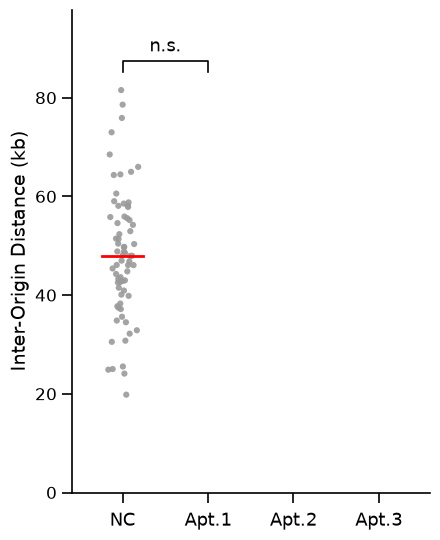

(<Figure size 450x550 with 1 Axes>,
 <Axes: ylabel='Inter-Origin Distance (kb)'>)

In [ ]:
boxplot_with_statistics(
        data = iod_kb_clean,
        var = "IOD_kb",
        sample_order = ['NC', 'Apt1', 'Apt2', 'Apt3'],
        sample_labels = {"NC": "NC", 'Apt1':"Apt1", 'Apt2':"Apt2", 'Apt3':"Apt3"},
        sample_colors = {"NC": "#9A9A9A", 'Apt1':"#252D8F", 'Apt2':"#E69F00", 'Apt3':"#D55E00"},
        sample_markers = {"NC": "o", 'Apt1':"o", 'Apt2':"o", 'Apt3':"o"},
        figsize = (4.5, 5.5),
        stats = [
        {
                "group1": "NC",
                "group2": "Apt1",
                "p_value": 1,
        }],
        y_axis = "Inter-Origin Distance (kb)",
        save_dir = OUTPUT_DIR,
        save_name = "IOD_kb",
        ext = "png"
)
        
        

### 8.2 Replication speed graph

In [ ]:
boxplot_with_statistics(
        data = replication_speed,
        var = "Speed_kb_min",
        sample_order = ['NC_RPMI_2h', 'ORC1-3_RPMI_2h'],
        sample_labels = {"NC_RPMI_2h": "NC", "ORC1-3_RPMI_2h": "Apt.3"},
        sample_colors = {"NC_RPMI_2h": "#9a9a9a", "ORC1-3_RPMI_2h": "#252D8F"},
        sample_markers = {"NC_RPMI_2h": "o", "ORC1-3_RPMI_2h": "^"},
        figsize = (4.5, 5.5),
        stats = [
        {
                "group1": "NC_RPMI_2h",
                "group2": "ORC1-3_RPMI_2h",
                "p_value": 8.287422e-07,
        }],
        y_axis = "Replication Speed (kb/min)",
        save_dir = OUTPUT_DIR,
        save_name = "Speed_kb_min",
        ext = "png"
)

In [ ]:
boxplot_with_statistics(
        data = speed_clean,
        var = "Speed_kb_min",
        sample_order = ['NC', 'ORC1'],
        sample_labels = {"NC": "NC", "ORC1": "Apt.3"},
        sample_colors = {"NC": "#9a9a9a", "ORC1": "#252D8F"},
        sample_markers = {"NC": "o", "ORC1": "^"},
        figsize = (4.5, 5.5),
        stats = [
        {
                "group1": "NC",
                "group2": "ORC1",
                "p_value": 0.003312,
        }],
        y_axis = "Replication Speed (kb/min)",
        save_dir = OUTPUT_DIR,
        save_name = "Speed_kb_min",
        ext = "png"
)